# Знакомство с `torch.Tensor`

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/torch.html


## Задачи для совместного разбора

1\. Создайте тензор и исследуйте его основные характеристики

2\. Создайте трехмерный тензор и рассмотрите основные способы индексирования по нему

3\. Создайте тензор (4х4) и модифицируйте следующим образом: ко всем четным столбцам прибавьте 1, из нечетных вычтите 1.

4\. Обсудите совместимость `torch` с `numpy` и `sklearn`

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Создайте двумерный тензор размера (100000, 10), заполненный нулями. Используя прихотливое индексирование, поставьте в каждой строке тензора ровно одну единицу в случайно выбранном столбце. Рассчитайте и выведите на экран вероятности $p_i$ того, что для случайно выбранной строки в столбце $i$ будет стоять единица.

- [ ] Проверено на семинаре

In [1]:
import torch

torch.manual_seed(42)

t = torch.zeros((100_000, 10), dtype=torch.float32)
rows = torch.arange(t.shape[0])
cols = torch.randint(0, t.shape[1], (t.shape[0],))

t[rows, cols] = 1

p = t.mean(dim=0)

print("Сумма вероятностей:", p.sum().item())
print("Вероятности p_i:")
print(p)


Сумма вероятностей: 1.0
Вероятности p_i:
tensor([0.1002, 0.0982, 0.0998, 0.1015, 0.0987, 0.1001, 0.0989, 0.1010, 0.1018,
        0.0999])


<p class="task" id="2"></p>

2\. При помощи прихотливого индексирования для двумерного тензора размерности (10, 10), состоящего из случайных целых чисел в пределах от 0 до 10, получите тензор элементов, находящихся сразу над  побочной диагональю.

- [ ] Проверено на семинаре

In [2]:
t = torch.randint(0, 11, (10, 10))

n = t.shape[0]
rows = torch.arange(n - 1)
cols = n - 2 - rows
above_secondary_diagonal = t[rows, cols]

print(t)
print("\nЭлементы над побочной диагональю:")
print(above_secondary_diagonal)


tensor([[ 1,  9,  6, 10,  9,  9,  1,  2,  5,  5],
        [ 9,  7, 10,  2,  2,  5,  5,  2,  5,  6],
        [ 5,  3,  3,  9,  2,  2,  8,  0,  7,  1],
        [ 9, 10, 10,  4,  5,  4,  3,  9,  1,  0],
        [ 7,  0,  7,  3,  2,  3,  2,  4,  0, 10],
        [ 2,  9,  9,  0,  9,  3,  7,  9,  3,  8],
        [ 5,  5,  4,  9, 10,  5,  8,  3,  7,  2],
        [ 0, 10,  2,  1,  9,  4,  1,  9, 10,  1],
        [ 9,  8,  4,  0,  3,  2,  3,  2,  0,  1],
        [ 0,  6,  9,  6,  4,  0,  0, 10,  0,  7]])

Элементы над побочной диагональю:
tensor([ 5,  2,  8,  4,  2,  0,  4, 10,  9])


<p class="task" id="3"></p>

3\. Создайте двумерный тензор $t$ размерности (5, 5), состоящий из случайных чисел в пределах от 0 до 100. Обнулить все значения в массиве, расположенные вне квадрата размера 3х3 вокруг максимального элемента. Если максимумов несколько, обнулите элементы около любого из них.

- [ ] Проверено на семинаре

In [3]:
t = torch.randint(0, 101, (5, 5))

max_flat_idx = torch.argmax(t)
max_row = max_flat_idx // t.shape[1]
max_col = max_flat_idx % t.shape[1]

row_start = torch.clamp(max_row - 1, min=0, max=t.shape[0] - 3)
col_start = torch.clamp(max_col - 1, min=0, max=t.shape[1] - 3)

row_idx = torch.arange(t.shape[0]).view(-1, 1)
col_idx = torch.arange(t.shape[1]).view(1, -1)

mask = (
    (row_idx >= row_start)
    & (row_idx < row_start + 3)
    & (col_idx >= col_start)
    & (col_idx < col_start + 3)
)

t_result = torch.where(mask, t, torch.zeros_like(t))

print("Исходный тензор:")
print(t)
print(f"\nМаксимум: {t[max_row, max_col].item()}, индекс: ({max_row.item()}, {max_col.item()})")
print("\nРезультат:")
print(t_result)


Исходный тензор:
tensor([[38, 34, 33, 27, 54],
        [35, 43, 45, 19,  7],
        [72, 83, 46, 86, 54],
        [33, 91, 40, 22, 66],
        [80, 97, 58, 67, 90]])

Максимум: 97, индекс: (4, 1)

Результат:
tensor([[ 0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0],
        [72, 83, 46,  0,  0],
        [33, 91, 40,  0,  0],
        [80, 97, 58,  0,  0]])


<p class="task" id="4"></p>

4\. Создайте трехмерный массив размерности (2, 5, 5) на основе решения задачи 3 (объедините исходный и результирущий тензор вдоль нулевой оси). Сохраните полученный трехмерный тензор в файл `tensor.pt`. Загрузите полученный тензор и покажите, что все элементы двух тензоров совпадают.

- [ ] Проверено на семинаре

In [4]:
t_3d = torch.stack((t, t_result), dim=0)

torch.save(t_3d, "tensor.pt")
t_loaded = torch.load("tensor.pt", weights_only=True)

print("Размер:", t_3d.shape)
print("Все элементы совпадают:", torch.equal(t_3d, t_loaded))


Размер: torch.Size([2, 5, 5])
Все элементы совпадают: True


<p class="task" id="5"></p>

5\. Создайте четырехмерный массив `t` размерности (2, 3, 5, 5), заполненный случайными целыми числами от 1 до 10 (сами значения должны быть представлены типом float32). Рассчитайте среднее значение для каждого двумерного тензора `t[i, j, :, :]`. Представьте результат в виде трехмерного тензора размера (2, 3, 1).

- [ ] Проверено на семинаре

In [5]:
t = torch.randint(1, 11, (2, 3, 5, 5), dtype=torch.int64).to(torch.float32)

mean_values = t.mean(dim=(2, 3)).unsqueeze(-1)

print("dtype:", t.dtype)
print("Размер результата:", mean_values.shape)
print(mean_values)


dtype: torch.float32
Размер результата: torch.Size([2, 3, 1])
tensor([[[6.0400],
         [4.9600],
         [5.5200]],

        [[4.8800],
         [6.0400],
         [5.9600]]])


<p class="task" id="6"></p>

6\. Создайте одномерный тензор размера `N=100_000_000`, заполненный числами из экспоненциального распредления с параметром $\lambda=5$. Рассчитайте значения для построения гистограммы при помощи пакета `torch`. Визуализируйте гистограмму. Проверьте возможность использования GPU. При наличии GPU перенесите созданный тензор в память GPU, повторите вычисления. Сравните время расчетом с и без использования GPU.

- [ ] Проверено на семинаре

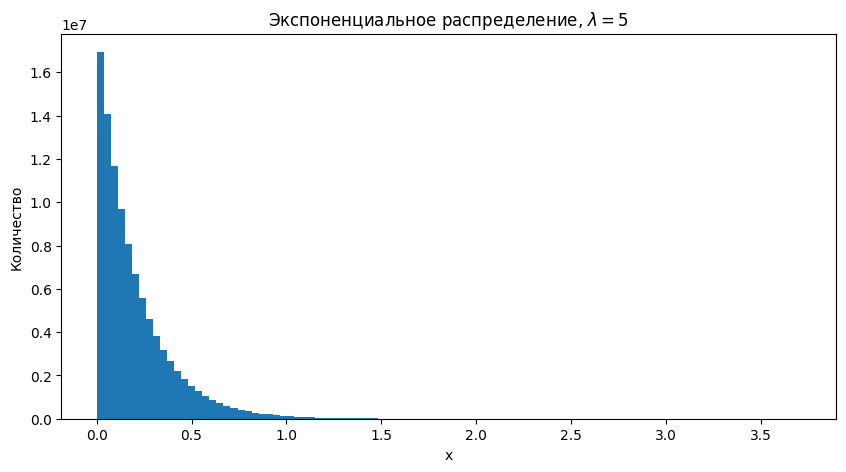

CPU: 0.0301 сек.
GPU: 0.0266 сек.
Ускорение CPU/GPU: 1.13x
Гистограммы совпадают: True


In [6]:
import time
import matplotlib.pyplot as plt

N = 100_000_000
lambd = 5.0
bins = 100

x = torch.empty(N, dtype=torch.float32).exponential_(lambd)
max_value = x.max().item()

start = time.perf_counter()
hist_cpu = torch.histc(x, bins=bins, min=0.0, max=max_value)
cpu_time = time.perf_counter() - start

bin_edges = torch.linspace(0.0, max_value, bins + 1)

plt.figure(figsize=(10, 5))
plt.bar(
    bin_edges[:-1].numpy(),
    hist_cpu.numpy(),
    width=(bin_edges[1] - bin_edges[0]).item(),
    align="edge",
)
plt.xlabel("x")
plt.ylabel("Количество")
plt.title(r"Экспоненциальное распределение, $\lambda=5$")
plt.show()

print(f"CPU: {cpu_time:.4f} сек.")

if torch.cuda.is_available():
    x_gpu = x.to("cuda")
    torch.cuda.synchronize()

    start = time.perf_counter()
    hist_gpu = torch.histc(x_gpu, bins=bins, min=0.0, max=max_value)
    torch.cuda.synchronize()
    gpu_time = time.perf_counter() - start

    print(f"GPU: {gpu_time:.4f} сек.")
    print(f"Ускорение CPU/GPU: {cpu_time / gpu_time:.2f}x")
    print("Гистограммы совпадают:", torch.allclose(hist_cpu, hist_gpu.cpu()))

    del x_gpu, hist_gpu
else:
    print("CUDA недоступна — сравнение с GPU пропущено.")


<p class="task" id="7"></p>

7\. Создайте четырехмерный тензор размера (10, 6, 6, 3), заполненный случайными целыми числами от 0 до 255. Считая, что данный тензор представляет собой батч из 10 картинок размера 6х6 в формате RGB, измените тензор следующим образом. Для оттенков красного обнулите все столбцы, кроме первых двух; для оттенков зеленого обнулите третий и четвертый столбцы; для оттенков синего обнулите пятый и шестой столбцы. Для выполнения задания используйте механизм распространения.

- [ ] Проверено на семинаре

In [7]:
t = torch.randint(0, 256, (10, 6, 6, 3))

mask = torch.ones((1, 1, 6, 3), dtype=t.dtype)

mask[:, :, 2:, 0] = 0
mask[:, :, 2:4, 1] = 0
mask[:, :, 4:, 2] = 0

t_result = t * mask

print("Размер результата:", t_result.shape)
print("\nМаска распространения:")
print(mask[0, 0])


Размер результата: torch.Size([10, 6, 6, 3])

Маска распространения:
tensor([[1, 1, 1],
        [1, 1, 1],
        [0, 0, 1],
        [0, 0, 1],
        [0, 1, 0],
        [0, 1, 0]])


## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ